In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import r2_score

In [ ]:
path = '../Erdos_Project/official_repo'
file = 'common_NPI_pushed_year'

In [ ]:
df = pd.read_csv(f'{path}/data/{file}.csv').drop('Unnamed: 0',axis=1)
df

,Rndrng_NPI,Tot_HCPCS_Cds,Tot_Benes,Tot_Srvcs,Tot_Sbmtd_Chrg,Tot_Mdcr_Alowd_Amt,Tot_Mdcr_Pymt_Amt,Bene_Avg_Age,Bene_Avg_Risk_Scre,pca_1,...,PharmacyNutrition_Tot_Risk_2,PharmacyNutrition_Tot_Risk_0,PharmacyNutrition_Tot_Risk_1,state_South,state_Midwest,state_Northeast,state_West,state_Territory,state_Military,state_Unknown
0,1003000126,22,665,1648.0,395335.0,146521.84,116332.66,74,2.1114,0.047429,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1003000134,13,3939,7517.0,1211425.0,282079.49,217960.62,76,1.0156,0.411904,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,1003000142,42,144,661.0,197224.0,63334.30,49752.77,63,1.5662,-0.096087,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,1003000407,37,436,1683.0,240818.0,174786.95,138741.21,76,1.8967,0.037454,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1003000423,33,63,320.0,31637.0,13176.47,10320.43,56,1.1882,-0.194836,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10196593,1992999551,26,230,1103.0,145838.0,86140.00,61178.65,77,1.0393,-0.084730,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
10196594,1992999569,4,15,25.0,3660.0,3159.02,2302.62,73,0.7647,-0.213209,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
10196595,1992999775,21,208,323.0,2774700.0,1209276.66,962418.78,74,0.9702,1.840767,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
10196596,1992999825,35,341,570.0,200383.3,80987.39,60559.67,75,1.0851,-0.075927,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


# Set-up the metrics

In [5]:
# if denominator(actual) <=0, replace by the smallest positive number

def mean_abs_log_ratio(actual,pred):
    if min(actual)<=0:
        m = sorted(actual.unique())[1]
    else: m = min(actual)
    actual = actual.apply(lambda x:x if x>0 else m)

    if min(pred)<=0:
        m = sorted(pred.apply(lambda x:x if x>0 else 0).unique())[1]
        pred = pred.apply(lambda x:x if x>0 else m)
    ratio = pred/actual
    return np.mean(np.abs(np.log(ratio)))

In [6]:
def mean_log_ratio(actual,pred):
    if min(actual)<=0:
        m = sorted(actual.unique())[1]
    else: m = min(actual)
    actual = actual.apply(lambda x:x if x>0 else m)

    if min(pred)<=0:
        m = sorted(pred.apply(lambda x:x if x>0 else 0).unique())[1]
        pred = pred.apply(lambda x:x if x>0 else m)
    ratio = pred/actual
    return np.mean(np.log(ratio))

# walk-forward validation

In [ ]:
def walkforward_LR(feature_cols,df,target_col):
    result = pd.DataFrame({})
    a = 0
    b = 0
    c = 0
    features = ''
    for f in feature_cols:
        features+=f'{f},'
    features = features[:-1]
    print(features)

    boo = ''
    if 'Log_' in target_col: boo='Y'
    else: boo='N'
    
    for year in [2018,2019,2020,2021,2022]:
        X_train = sm.add_constant(df[df['current_year']<year][feature_cols])
        X_val = sm.add_constant(df[df['current_year']==year][feature_cols])

        y_train = df[df['current_year']<year][target_col]

        LR = sm.OLS(y_train,X_train).fit()

        if 'Log_' in target_col:
            log_val = df[df['current_year']==year][target_col]
            y_val = np.exp(log_val)
            log_pred = LR.predict(X_val)
            y_pred = np.exp(log_pred)
        else:
            y_pred = LR.predict(X_val)
            y_val = df[df['current_year']==year][target_col]

        result['log'] = [f'{boo}']
        result['features'] = [f'{features}']
        result['num_features'] = [len(feature_cols)]
        result[f'mlr_{year}'] = [mean_log_ratio(y_val,y_pred)]
        a+=mean_log_ratio(y_val,y_pred)
        result[f'malr_{year}'] = [mean_abs_log_ratio(y_val,y_pred)]
        b+=mean_abs_log_ratio(y_val,y_pred)
        if 'Log_' in target_col:
            result[f'R2_{year}'] = [r2_score(log_val,log_pred)]
            c+=r2_score(log_val,log_pred)
        else:
            result[f'R2_{year}'] = [r2_score(y_val,y_pred)]
            c+=r2_score(y_val,y_pred)
    result['mlr']=[a/5]
    result['malr']=[b/5]
    result['R2']=[c/5]
    result['abs_mlr'] = [abs(a/5)]

    print(result)
    return result

In [ ]:
# initialize the result dataframe
RESULT_DF = pd.DataFrame(columns = ['log','features','num_features','malr_2018','mlr_2018','R2_2018','malr_2019','mlr_2019','R2_2019','malr_2020','mlr_2020','R2_2020','malr_2021','mlr_2021','R2_2021','malr_2022','mlr_2022','R2_2022','malr','mlr','R2','abs_mlr'])
RESULT_DF

,log,features,num_features,malr_2018,mlr_2018,R2_2018,malr_2019,mlr_2019,R2_2019,malr_2020,...,malr_2021,mlr_2021,R2_2021,malr_2022,mlr_2022,R2_2022,malr,mlr,R2,abs_mlr


set up feature selection storage dataframe

# forward feature selection Log

In [11]:
all_features = [c for c in df.columns if c not in ['Tot_Mdcr_Pymt_Amt_current','Log_Tot_Mdcr_Pymt_Amt_current','Rndrng_NPI']]

In [ ]:
RESULT_DF = pd.read_csv(f'{path}/results/feature_selection_with_intercept.csv')
RESULT_DF[RESULT_DF['log']=='Y'].sort_values('R2',ascending=False)
#RESULT_DF.sort_values('malr')

,log,features,num_features,malr_2018,mlr_2018,R2_2018,malr_2019,mlr_2019,R2_2019,malr_2020,...,malr_2021,mlr_2021,R2_2021,malr_2022,mlr_2022,R2_2022,malr,mlr,R2,abs_mlr
1302,Y,"Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...",15,0.371955,0.008017,0.829372,0.375021,-0.004822,0.829349,0.433855,...,0.427841,-0.134832,0.795591,0.405130,0.078069,0.797464,0.402761,0.025771,0.808689,0.025771
1253,Y,"Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...",14,0.372011,0.007871,0.829335,0.375131,-0.005083,0.829288,0.433787,...,0.428026,-0.135227,0.795423,0.405181,0.077821,0.797356,0.402827,0.025504,0.808617,0.025504
1303,Y,"Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...",15,0.372095,0.007995,0.829305,0.375137,-0.004835,0.829291,0.434136,...,0.427901,-0.134846,0.795510,0.405335,0.078152,0.797384,0.402921,0.025781,0.808616,0.025781
1305,Y,"Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...",15,0.372079,0.008098,0.829285,0.375118,-0.004740,0.829285,0.434217,...,0.427888,-0.134801,0.795497,0.405330,0.078207,0.797407,0.402926,0.025862,0.808607,0.025862
1254,Y,"Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...",14,0.372155,0.007838,0.829265,0.375254,-0.005109,0.829227,0.434071,...,0.428093,-0.135257,0.795334,0.405390,0.077899,0.797272,0.402992,0.025502,0.808540,0.025502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42,Y,LabPathology_Tot_Risk_2,1,1.162710,0.038240,-0.000682,1.157457,0.024807,-0.000286,1.163216,...,1.118204,-0.014581,-0.000112,1.123221,0.062341,-0.001871,1.144962,0.056637,-0.003306,0.056637
51,Y,state_West,1,1.162685,0.038137,-0.000402,1.157504,0.024730,-0.000094,1.163398,...,1.118496,-0.014582,-0.000442,1.123554,0.062292,-0.002265,1.145128,0.056591,-0.003378,0.056591
10,Y,Cd_I,1,1.156566,0.040261,-0.002451,1.152381,0.026935,-0.002130,1.161990,...,1.123778,-0.013579,-0.010115,1.124954,0.062605,-0.005543,1.143934,0.058078,-0.007876,0.058078
11,Y,Cd_O,1,1.156566,0.040261,-0.002451,1.152381,0.026935,-0.002130,1.161990,...,1.123778,-0.013579,-0.010115,1.124954,0.062605,-0.005543,1.143934,0.058078,-0.007876,0.058078


In [290]:
pre_best = RESULT_DF[RESULT_DF['log']=='Y'].sort_values('R2',ascending=False).iat[7,1].split(',')
remaining_features = [c for c in all_features if c not in pre_best and c!='Is_Covid']
pre_best

['Log_Tot_Mdcr_Pymt_Amt',
 'Log_Tot_Mdcr_Alowd_Amt',
 'Tot_HCPCS_Cds',
 'Type_Anesthesia',
 'Bene_Avg_Age',
 'Log_Tot_Benes',
 'Type_MedicalSpecialtyOther',
 'Type_OBGYN',
 'Type_Cardiology',
 'APP_Tot_Risk_2',
 'Type_RehabTherapy',
 'state_Territory',
 'Type_BehavioralHealth',
 'PrimaryCare_Tot_Risk_2',
 'PharmacyNutrition_Tot_Risk_2']

In [277]:
for c in remaining_features: # run this line if it's NOT the very first iteration
#for c in all_features: # run this line if it's the very first iteration
    try:
        result = walkforward_LR(pre_best+[c],df,'Log_Tot_Mdcr_Pymt_Amt_current') # run this line if it's NOT the very first iteration
        #result = walkforward_LR([c],df,'Log_Tot_Mdcr_Pymt_Amt_current') # run this line if it's the very first iteration
        RESULT_DF = pd.concat([RESULT_DF, result], ignore_index=True)
    except ValueError: 
        continue

Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,Tot_HCPCS_Cds,Type_Anesthesia,Bene_Avg_Age,Log_Tot_Benes,Type_MedicalSpecialtyOther,Type_OBGYN,Type_Cardiology,APP_Tot_Risk_2,Type_RehabTherapy,state_Territory,Type_BehavioralHealth,PrimaryCare_Tot_Risk_2,Tot_Benes
  log                                           features  num_features  \
0   Y  Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...            15   

   mlr_2018  malr_2018   R2_2018  mlr_2019  malr_2019  R2_2019  mlr_2020  ...  \
0  0.007922   0.372388  0.829129 -0.004915   0.375391  0.82915  0.182426  ...   

   mlr_2021  malr_2021   R2_2021  mlr_2022  malr_2022   R2_2022       mlr  \
0 -0.135009   0.428148  0.795257   0.07828   0.405866  0.797217  0.025741   

       malr       R2   abs_mlr  
0  0.403339  0.80843  0.025741  

[1 rows x 22 columns]
Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,Tot_HCPCS_Cds,Type_Anesthesia,Bene_Avg_Age,Log_Tot_Benes,Type_MedicalSpecialtyOther,Type_OBGYN,Type_Cardiology,APP_Tot_Risk_2,Type_RehabThe

In [ ]:
RESULT_DF.to_csv(f'{path}/results/feature_selection_with_intercept.csv',index=False)

## check on model

In [291]:
feature_cols = RESULT_DF[RESULT_DF['log']=='Y'].sort_values('R2',ascending=False).iat[7,1].split(',')
feature_cols

['Log_Tot_Mdcr_Pymt_Amt',
 'Log_Tot_Mdcr_Alowd_Amt',
 'Tot_HCPCS_Cds',
 'Type_Anesthesia',
 'Bene_Avg_Age',
 'Log_Tot_Benes',
 'Type_MedicalSpecialtyOther',
 'Type_OBGYN',
 'Type_Cardiology',
 'APP_Tot_Risk_2',
 'Type_RehabTherapy',
 'state_Territory',
 'Type_BehavioralHealth',
 'PrimaryCare_Tot_Risk_2',
 'PharmacyNutrition_Tot_Risk_2']

In [18]:
CHECK_MODEL_DF = pd.DataFrame(columns=['log','features','malr','mlr','R2(log)','R2'])

In [233]:
def check_model(feature_cols,df,target_col):
    result = pd.DataFrame({})

    features = ''
    for c in feature_cols:
        features+=f'{c},'
    features = features[:-1]

    boo = ''

    X_train = sm.add_constant(df[df['current_year']<2023][feature_cols])
    X_test = sm.add_constant(df[df['current_year']==2023][feature_cols])

    y_train = df[df['current_year']<2023][target_col]

    LR = sm.OLS(y_train,X_train).fit()

    if 'Log_' in target_col:
        boo = 'Y'
        log_pred = LR.predict(X_test)
        y_pred = np.exp(log_pred)
        log_test = df[df['current_year']==2023][target_col]
        y_test = df[df['current_year']==2023][f'{target_col[4:]}']
    else:
        boo = 'N'
        y_pred = LR.predict(X_test)
        y_test = df[df['current_year']==2023][target_col]

    result['log'] = [boo]
    result['features'] = [features]
    result['num_features'] = [len(feature_cols)]
    result['malr'] = [round(mean_abs_log_ratio(y_test,y_pred),8)]
    result['mlr'] = [round(mean_log_ratio(y_test,y_pred),8)]
    if 'Log_' in target_col:
        result['R2(log)'] = [round(r2_score(log_test,log_pred),8)]
    else: result['R2(log)'] = [np.nan]
    result['R2'] = [round(r2_score(y_test,y_pred),8)]

    mn = min(min(y_test),min(y_pred))
    mx = max(max(y_test),max(y_pred))

    plt.scatter(y_test,y_pred,alpha=0.5)
    plt.xlim(mn,mx)
    plt.ylim(mn,mx)
    plt.xlabel('year 2023 actual spending')
    plt.ylabel('year 2023 predicted spending')
    plt.title('actual vs predicted (1 year lag)')

    print(LR.summary())

    return result


                                  OLS Regression Results                                 
Dep. Variable:     Log_Tot_Mdcr_Pymt_Amt_current   R-squared:                       0.821
Model:                                       OLS   Adj. R-squared:                  0.821
Method:                            Least Squares   F-statistic:                 2.763e+06
Date:                           Wed, 18 Mar 2026   Prob (F-statistic):               0.00
Time:                                   14:36:33   Log-Likelihood:            -8.5627e+06
No. Observations:                        9061686   AIC:                         1.713e+07
Df Residuals:                            9061670   BIC:                         1.713e+07
Df Model:                                     15                                         
Covariance Type:                       nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
---

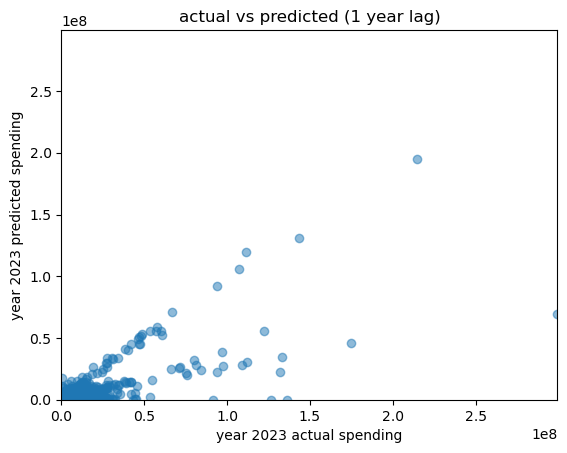

In [292]:
result = check_model(feature_cols,df,'Log_Tot_Mdcr_Pymt_Amt_current')

In [ ]:
CHECK_MODEL_DF = pd.read_csv(f'{path}/results/model_comparison_with_intercept.csv')
CHECK_MODEL_DF = pd.concat([CHECK_MODEL_DF,result],ignore_index=True)
CHECK_MODEL_DF = CHECK_MODEL_DF.drop_duplicates()
CHECK_MODEL_DF

,log,features,malr,mlr,R2(log),R2,num_features
0,N,"Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O",0.422747,0.169263,NaN,8.172958e-01,3
1,Y,"Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...",0.404265,0.020639,0.800698,6.475503e-01,3
2,N,"Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O...",0.423558,0.167956,NaN,8.173010e-01,4
3,Y,"Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...",0.401073,0.028755,0.802116,6.281777e-01,5
4,Y,"Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...",0.401681,0.033198,0.802663,6.069175e-01,6
5,Y,"Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...",0.401788,0.033433,0.803000,5.940169e-01,7
6,N,"Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O...",0.427668,0.174100,NaN,8.173008e-01,5
7,N,"Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O...",0.429154,0.175158,NaN,8.173026e-01,6
8,N,"Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O...",0.434767,0.169742,NaN,8.173025e-01,8
9,Y,"Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...",0.401315,0.034109,0.803639,-1.059774e+07,10


In [ ]:
CHECK_MODEL_DF.to_csv(f'{path}/results/model_comparison_with_intercept.csv',index=False)

# forward feature selection on non-log

In [ ]:
# get all features
# run this line if it's the very first iteration
all_features = [c for c in df.columns if c not in ['Tot_Mdcr_Pymt_Amt_current','Log_Tot_Mdcr_Pymt_Amt_current','Rndrng_NPI','Is_Covid']]

In [ ]:
RESULT_DF = pd.read_csv(f'{path}/results/feature_selection_with_intercept.csv') # read lastest results
RESULT_DF[RESULT_DF['log']=='N'].sort_values('R2',ascending=False) # rank non-log results by R2
#RESULT_DF.sort_values('malr')

,log,features,num_features,malr_2018,mlr_2018,R2_2018,malr_2019,mlr_2019,R2_2019,malr_2020,...,malr_2021,mlr_2021,R2_2021,malr_2022,mlr_2022,R2_2022,malr,mlr,R2,abs_mlr
1387,N,"Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O...",10,0.480710,0.285427,0.930564,0.443958,0.217127,8.819684e-01,0.545050,...,0.427480,0.063317,0.869404,0.456435,0.218178,0.902358,0.470727,0.235161,0.894474,0.235161
1372,N,"Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O...",10,0.480710,0.285427,0.930564,0.443958,0.217127,8.819684e-01,0.545050,...,0.427480,0.063317,0.869404,0.456435,0.218178,0.902358,0.470727,0.235161,0.894474,0.235161
1386,N,"Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O...",10,0.480710,0.285427,0.930564,0.443958,0.217127,8.819684e-01,0.545050,...,0.427480,0.063317,0.869404,0.456435,0.218178,0.902358,0.470727,0.235161,0.894474,0.235161
1391,N,"Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O...",10,0.480673,0.286831,0.930564,0.444256,0.218194,8.819682e-01,0.545899,...,0.427850,0.064199,0.869404,0.455477,0.220024,0.902357,0.470831,0.236356,0.894474,0.236356
1392,N,"Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O...",10,0.480670,0.286832,0.930564,0.445892,0.216571,8.819682e-01,0.545898,...,0.427848,0.064197,0.869404,0.455478,0.220014,0.902357,0.471157,0.236028,0.894474,0.236028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,N,state_Military,1,1.463589,1.123252,-0.000002,1.458727,1.115779,-4.227451e-07,1.559093,...,1.426129,1.094580,-0.000006,1.479375,1.171978,-0.000025,1.477383,1.154909,-0.000051,1.154909
116,N,state_Unknown,1,1.463600,1.123262,-0.000002,1.458702,1.115677,-1.309615e-06,1.559108,...,1.426143,1.094600,-0.000007,1.479394,1.172007,-0.000026,1.477389,1.154906,-0.000052,1.154906
91,N,Type_UnknownOther,1,1.463684,1.123363,-0.000010,1.458758,1.115829,-2.287825e-06,1.559100,...,1.426122,1.094573,-0.000006,1.479370,1.171981,-0.000025,1.477407,1.154945,-0.000053,1.154945
107,N,PharmacyNutrition_Tot_Risk_2,1,1.461027,1.120712,0.000020,1.455421,1.112295,-6.382265e-05,1.557475,...,1.425118,1.093645,-0.000027,1.478348,1.171054,-0.000029,1.475478,1.153061,-0.000072,1.153061


In [301]:
pre_best = RESULT_DF[RESULT_DF['log']=='N'].sort_values('R2',ascending=False).iat[0,1].split(',') # get the best R2 features
remaining_features = [c for c in all_features if c not in pre_best and c!='Is_Covid'] # get the features excluding the best R2 features
pre_best

['Tot_Mdcr_Pymt_Amt',
 'LabPathology_Tot_Risk_0',
 'Cd_O',
 'state_West',
 'PrimaryCare_Tot_Risk_1',
 'Type_AcuteCare',
 'state_Territory',
 'PharmacyNutrition_Tot_Risk_1',
 'MedicalSpecialtyOther_Tot_Risk_1',
 'PharmacyNutrition_Tot_Risk_0']

In [297]:
start = 0
interrupt = 0

In [298]:
#for i in range(start,len(all_features)): # run this line if it's the very first iteration
for i in range(start,len(remaining_features)): # run this line if it's NOT the very first iteration
    #c = all_features[i] # run this line if it's the very first iteration
    c = remaining_features[i] # run this line if it's NOT the very first iteration
    interrupt = i
    try:
        #result = walkforward_LR([c],df,'Tot_Mdcr_Pymt_Amt_current')
        result = walkforward_LR(pre_best+[c],df,'Tot_Mdcr_Pymt_Amt_current')
        RESULT_DF = pd.concat([RESULT_DF, result], ignore_index=True)
    except ValueError: 
        continue

Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O,state_West,PrimaryCare_Tot_Risk_1,Type_AcuteCare,state_Territory,PharmacyNutrition_Tot_Risk_1,MedicalSpecialtyOther_Tot_Risk_1,Tot_HCPCS_Cds
  log                                           features  num_features  \
0   N  Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O...            10   

   mlr_2018  malr_2018   R2_2018  mlr_2019  malr_2019   R2_2019  mlr_2020  \
0  0.119431   0.440704  0.930271  0.098964   0.420087  0.881871  0.311491   

   ...  mlr_2021  malr_2021   R2_2021  mlr_2022  malr_2022   R2_2022  \
0  ... -0.062602    0.43863  0.869236  0.154558   0.448249  0.902325   

        mlr      malr        R2   abs_mlr  
0  0.124368  0.453235  0.894372  0.124368  

[1 rows x 22 columns]
Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O,state_West,PrimaryCare_Tot_Risk_1,Type_AcuteCare,state_Territory,PharmacyNutrition_Tot_Risk_1,MedicalSpecialtyOther_Tot_Risk_1,Tot_Benes
  log                                           features  num_featur

In [ ]:
RESULT_DF.to_csv(f'{path}/results/feature_selection_with_intercept.csv',index=False)

## check on model

In [302]:
feature_cols = RESULT_DF[RESULT_DF['log']=='N'].sort_values('R2',ascending=False).iat[0,1].split(',')
feature_cols

['Tot_Mdcr_Pymt_Amt',
 'LabPathology_Tot_Risk_0',
 'Cd_O',
 'state_West',
 'PrimaryCare_Tot_Risk_1',
 'Type_AcuteCare',
 'state_Territory',
 'PharmacyNutrition_Tot_Risk_1',
 'MedicalSpecialtyOther_Tot_Risk_1',
 'PharmacyNutrition_Tot_Risk_0']

                                OLS Regression Results                               
Dep. Variable:     Tot_Mdcr_Pymt_Amt_current   R-squared:                       0.893
Model:                                   OLS   Adj. R-squared:                  0.893
Method:                        Least Squares   F-statistic:                 7.534e+06
Date:                       Wed, 18 Mar 2026   Prob (F-statistic):               0.00
Time:                               15:13:00   Log-Likelihood:            -1.2340e+08
No. Observations:                    9061686   AIC:                         2.468e+08
Df Residuals:                        9061675   BIC:                         2.468e+08
Df Model:                                 10                                         
Covariance Type:                   nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

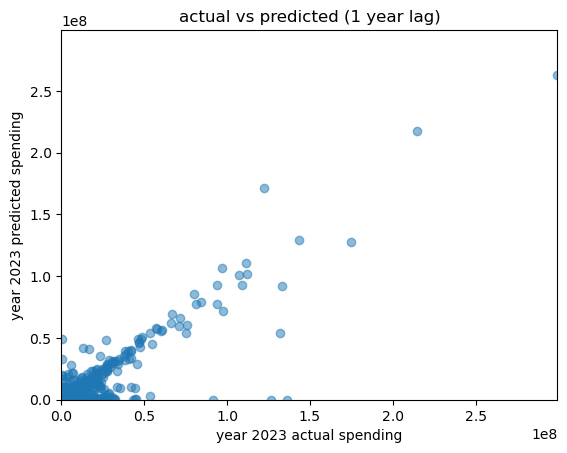

In [303]:
result = check_model(feature_cols,df,'Tot_Mdcr_Pymt_Amt_current')

In [ ]:
CHECK_MODEL_DF = pd.read_csv(f'{path}/results/model_comparison_with_intercept.csv')
CHECK_MODEL_DF = pd.concat([CHECK_MODEL_DF,result],ignore_index=True)
CHECK_MODEL_DF = CHECK_MODEL_DF.drop_duplicates()
CHECK_MODEL_DF

,log,features,malr,mlr,R2(log),R2,num_features
0,N,"Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O",0.422747,0.169263,NaN,8.172958e-01,3
1,Y,"Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...",0.404265,0.020639,0.800698,6.475503e-01,3
2,N,"Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O...",0.423558,0.167956,NaN,8.173010e-01,4
3,Y,"Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...",0.401073,0.028755,0.802116,6.281777e-01,5
4,Y,"Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...",0.401681,0.033198,0.802663,6.069175e-01,6
5,Y,"Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...",0.401788,0.033433,0.803000,5.940169e-01,7
6,N,"Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O...",0.427668,0.174100,NaN,8.173008e-01,5
7,N,"Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O...",0.429154,0.175158,NaN,8.173026e-01,6
8,N,"Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O...",0.434767,0.169742,NaN,8.173025e-01,8
9,Y,"Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...",0.401315,0.034109,0.803639,-1.059774e+07,10


In [ ]:
CHECK_MODEL_DF.to_csv(f'{path}/results/model_comparison_with_intercept.csv',index=False)

If add an intercept, regress on log amount performs better than regress on non-log amount.